In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C:\Users\Consultor\Desktop\Estadistica-py-main\BD\06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109193,1048489,Masculino,40,40 y mas,2015,Segundo semestre,Universidades Privadas,UNIVERSIDAD DE LAS AMERICAS,ACREDITADA,17/03/2019 AL 17/03/2023,...,Carreras Profesionales,Ciencias Sociales,11,0,11,170000,4000000,Valparaiso,Valparaiso,Vina Del Mar
109194,1048493,Masculino,23,20 a 24,2021,Primer semestre,Institutos Profesionales,IP DUOC UC,ACREDITADA,26/08/2017 AL 26/08/2024,...,Carreras Tecnicas,Ciencias Basicas,5,1,5,176000,2060000,Valparaiso,Valparaiso,Valparaiso
109195,1048494,Masculino,23,20 a 24,2017,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE PLAYA ANCHA DE CIENCIAS DE LA E...,ACREDITADA,27/09/2016 AL 27/09/2021,...,Carreras Profesionales,Educacion,9,1,9,152000,2465000,Valparaiso,Valparaiso,Valparaiso
109196,1048503,Masculino,35,35 a 39,2020,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Tecnicas,Administracion y Comercio,5,1,5,190000,1880000,Valparaiso,San Antonio,San Antonio


In [6]:

# Seleccionar columnas necesarias y eliminar valores nulos
df_simple = df[["NOMBRE CARRERA", "VALOR ARANCEL (PESOS)"]].dropna()
df_simple


,NOMBRE CARRERA,VALOR ARANCEL (PESOS)
0,FONOAUDIOLOGIA,3713000
1,CONTADOR AUDITOR CON MENCION BANCA E INSTITUCI...,1900000
2,INGENIERIA DE EJECUCION EN ADMINISTRACION DE E...,1760000
3,PEDAGOGIA EN BIOLOGIA Y CIENCIAS NATURALES Y/O...,2558000
4,ARQUITECTURA,4350000
...,...,...
109193,PSICOLOGIA,4000000
109194,TECNICO EN GEOLOGIA Y CONTROL EN SONDAJE,2060000
109195,PEDAGOGIA EN EDUCACION FISICA VARONES,2465000
109196,TECNICO EN OPERACIONES LOGISTICAS,1880000


In [7]:
# Agrupar por carrera y calcular el arancel promedio
top_carreras = df_simple.groupby("NOMBRE CARRERA")["VALOR ARANCEL (PESOS)"].mean().sort_values(ascending=False).head(5)
top_carreras

NOMBRE CARRERA
PROGRAMA DE ESPECIALIZACION EN ORTODONCIA Y ORTOPEDIA DENTOMAXILOFACIAL    11500000.0
MAGISTER EN MODELAMIENTO GEOESTADISTICO DE DEPOSITOS MINERALES             10135467.0
ESPECIALIDAD EN ORTODONCIA Y ORTOPEDIA DENTO MAXILO FACIAL                  9600000.0
ESPECIALIDAD CIRUGIA Y TRAUMATOLOGIA BUCO Y MAXILO FACIAL                   8755000.0
ESPECIALIDAD EN ENDODONCIA                                                  8448000.0
Name: VALOR ARANCEL (PESOS), dtype: float64

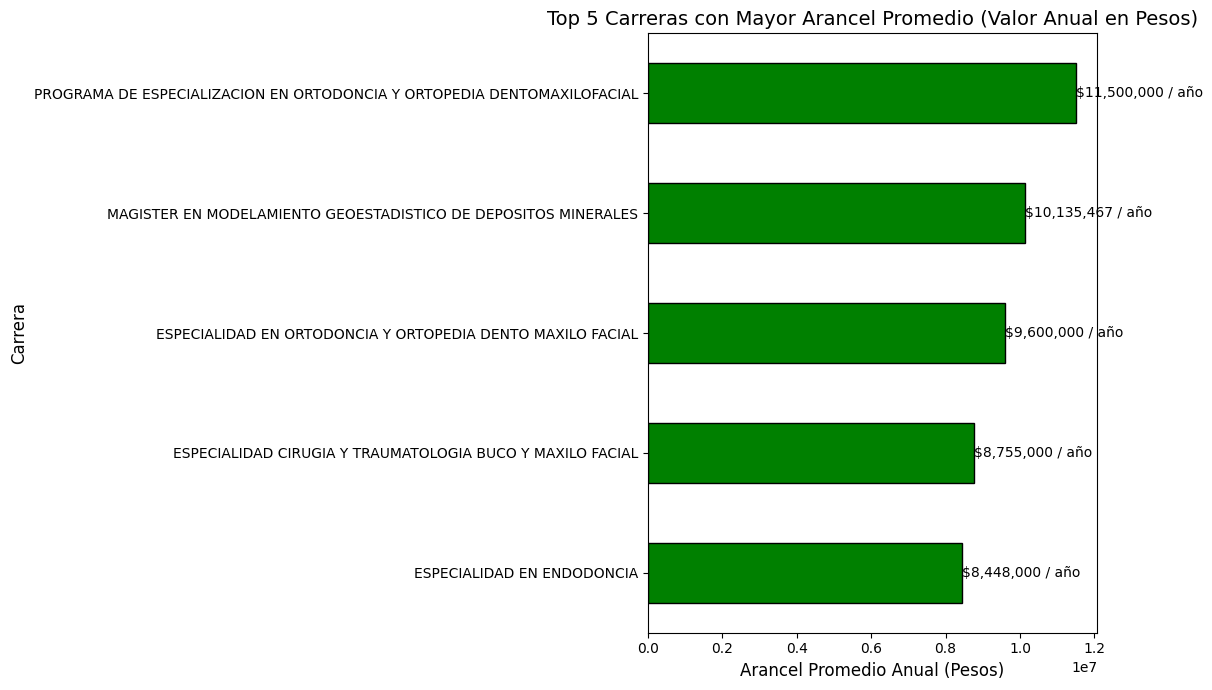

In [8]:
# Crear gráfico de barras horizontal
plt.figure(figsize=(12, 7))
bars = top_carreras.plot(kind="barh", color="green", edgecolor="black")
plt.title("Top 5 Carreras con Mayor Arancel Promedio (Valor Anual en Pesos)", fontsize=14)
plt.xlabel("Arancel Promedio Anual (Pesos)", fontsize=12)
plt.ylabel("Carrera", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().invert_yaxis()

# Agregar etiquetas de valor en cada barra
for i, (value, name) in enumerate(zip(top_carreras.values, top_carreras.index)):
    plt.text(value, i, f"${value:,.0f} / año", va='center', ha='left', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Sí, existen carreras cuyo arancel es sustantivamente más alto que el promedio general. Estas carreras se concentran principalmente en el área de Salud, como:

Medicina
Odontología
Fonoaudiología
Especialidades médicas y magísteres clínicos
Las razones detrás de estos altos costos incluyen:

Duración extensa: muchas de estas carreras tienen entre 10 y 12 semestres, lo que implica más años de matrícula.
Infraestructura especializada: requieren laboratorios, clínicas, equipamiento médico y prácticas supervisadas.
Alta demanda laboral y prestigio profesional: son carreras con alta empleabilidad y reconocimiento social.

Contexto regional:
En la región de Valparaíso, estas carreras se concentran en universidades con facultades consolidadas en salud y tecnología, lo que refuerza su relevancia académica y económica.